

##  Authors

| Name                          | Email                        | Username |
|-------------------------------|------------------------------|----------|
| **Umang Pankajbhai Dholakiya** | u.dholakiya@oth-aw.de        | `9826`   |
| **Aesha Dilipbhai Gadhiya**    | a.gadhiya@oth-aw.de          | `d8a0`   |

---

> This project was collaboratively developed as part of academic and research work related to indoor localization using IMU and BLE beacons.


## Map-Based Sensor Fusion for Indoor Localization Using a Particle Filter

## Floor plan

### floor map using Numpy matrix 

#### Create the floor plan using the numpy matrix with accurate measurements of the Indoor plan
- Also added the Beacons, initial position and last position 

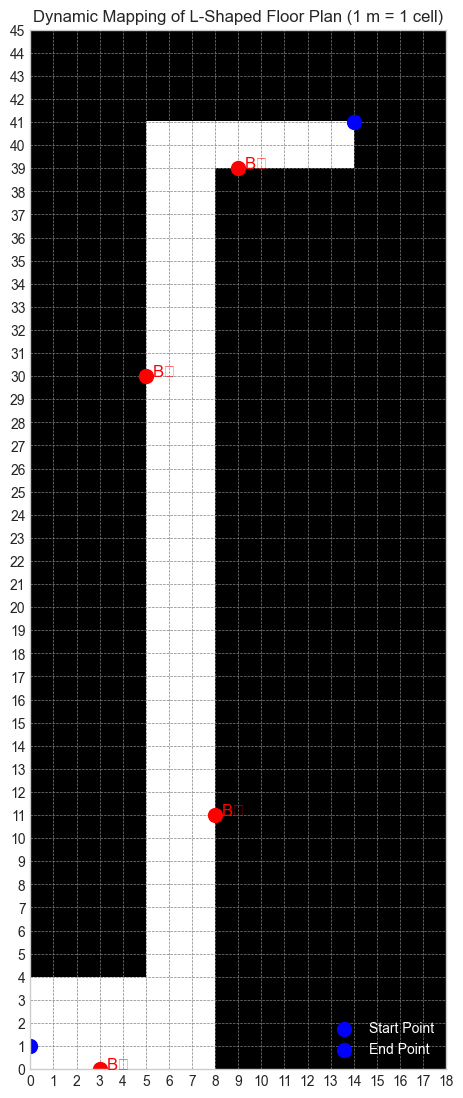

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the size of the grid map (1 meter = 1 cell)
height = 45  # rows
width  = 18  # cols

# Create a blank grid
floor_map = np.zeros((height, width), dtype=int)
floor_map[0:4,   0:8]  = 1   # Bottom horizontal part (8m x 4m)
floor_map[0:4,   0:6]  = 1   # Left horizontal extension (6m x 4m)
floor_map[4:39,  5:8]  = 1   # Vertical corridor (3m x 41m)
floor_map[39:41, 5:14] = 1   # Top corridor (8m x 2m)

# Desired cell size (in pixels)
CELL_PX = 30
DPI = 100
cell_in = CELL_PX / DPI

# Plot setup
plt.figure(figsize=(width * cell_in, height * cell_in), dpi=DPI)
plt.imshow(floor_map[::-1], cmap='Greys_r',
           extent=[0, width, 0, height],
           interpolation='none')
plt.title("Dynamic Mapping of L-Shaped Floor Plan (1 m = 1 cell)")

# Start and end
start = (0, 1)
end   = (14, 41)
plt.scatter(*start, c='blue', s=100, label='Start Point')
plt.scatter(*end,   c='blue', s=100, label='End Point')

# Beacons
beacons = {
    "B₁": (3, 0),
    "B₂": (8, 11),
    "B₃": (5, 30),
    "B₄": (9, 39)
}
for label, (x, y) in beacons.items():
    plt.scatter(x, y, c='red', s=100)
    plt.text(x + 0.3, y, label, color='red', fontsize=12)

# Grid and labels
plt.grid(True, which='major', color='gray', linestyle='--', linewidth=0.5)
plt.xticks(np.arange(0, width + 1, 1))
plt.yticks(np.arange(0, height + 1, 1))
plt.gca().set_aspect('equal', adjustable='box')

legend = plt.legend(loc='lower right')  # Create legend
for text in legend.get_texts():         # Change text color to white
    text.set_color("white")

plt.show()


### Pygame floor map

- Convert the Numpy Matrix map to 'PYGAME'

In [ ]:
import pygame
import numpy as np

#  Parameters 
CELL_PX = 20
WIDTH = 18   # columns
HEIGHT = 45  # rows

# Colors
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
BLUE  = (0, 0, 255)
RED   = (255, 0, 0)

#  Floor Map 
def build_floor_map():
    fmap = np.zeros((HEIGHT, WIDTH), dtype=int)
    fmap[0:4,   0:8]  = 1   # Bottom horizontal part
    fmap[0:4,   0:6]  = 1   # Left extension (partially overlaps with the above)
    fmap[4:39,  5:8]  = 1   # Vertical corridor
    fmap[39:41, 5:14] = 1   # Top corridor
    return fmap

#  Main Drawing 
def draw_map(screen, fmap, start, end, beacons):
    screen.fill(WHITE)  # Full background is white

    # Draw only the walls (borders between floor and non-floor)
    for y in range(HEIGHT):
        for x in range(WIDTH):
            if fmap[y, x] == 1:  # Floor cell
                # Calculate screen coordinates for the cell's top-left corner.
                # The y-coordinate is inverted for Pygame's coordinate system.
                screen_x = x * CELL_PX
                screen_y = (HEIGHT - 1 - y) * CELL_PX

                # Check neighbor above (in map y+1)
                # If it's the edge of the map or the neighbor is not floor, draw a wall line.
                if y + 1 >= HEIGHT or fmap[y + 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x + CELL_PX, screen_y), 2)

                # Check neighbor below (in map y-1)
                if y - 1 < 0 or fmap[y - 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y + CELL_PX), (screen_x + CELL_PX, screen_y + CELL_PX), 2)

                # Check neighbor to the right (in map x+1)
                if x + 1 >= WIDTH or fmap[y, x + 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x + CELL_PX, screen_y), (screen_x + CELL_PX, screen_y + CELL_PX), 2)

                # Check neighbor to the left (in map x-1)
                if x - 1 < 0 or fmap[y, x - 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x, screen_y + CELL_PX), 2)

    # Start and End points
    sx, sy = start
    ex, ey = end
    pygame.draw.circle(screen, BLUE, (int(sx * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - sy) * CELL_PX + CELL_PX / 2)), 6)
    pygame.draw.circle(screen, BLUE, (int(ex * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - ey) * CELL_PX + CELL_PX / 2)), 6)

    # Beacons with labels
    font = pygame.font.SysFont('Arial', 12)
    for label, (bx, by) in beacons.items():
        cx = int(bx * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - by) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, RED, (cx, cy), 6)
        text = font.render(label, True, RED)
        screen.blit(text, (cx + 5, cy - 5))

    pygame.display.flip()

#  Pygame App 
def main():
    """
    Initializes Pygame and runs the main application loop.
    """
    pygame.init()
    screen = pygame.display.set_mode((WIDTH * CELL_PX, HEIGHT * CELL_PX))
    pygame.display.set_caption("Dynamic Mapping of L-Shaped Floor Plan")

    fmap = build_floor_map()
    start = (0, 1)
    end = (13, 40)
    beacons = {
        "B₁": (3, 0),
        "B₂": (7, 11),
        "B₃": (5, 30),
        "B₄": (9, 39)
    }

    running = True
    while running:
        draw_map(screen, fmap, start, end, beacons)
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

    pygame.quit()

#  Run 
if __name__ == "__main__":
    main()


## Data recording

### Step:1 Fatching the devices (Beacons)

In [ ]:
import serial
import time

# Serial Configuration
PORT = "COM7" 
BAUD_RATE = 115200

# Start Serial Connection
ser = serial.Serial(PORT, BAUD_RATE, timeout=1)
time.sleep(2)  

print("Real-Time IMU + BLE Monitor")
print("Press Ctrl+C to stop.\n")

try:
    while True:
        # Read line from serial
        line = ser.readline().decode('utf-8').strip()
        if line:
            try:
                parts = line.split(",")
                if len(parts) == 10:
                    # Extract values
                    yaw_str, ax, ay, az, gx, gy, gz, device_name, device_address, rssi = parts
                    
                    # Convert yaw to float (no wrapping or offset)
                    yaw = float(yaw_str)

                    # Get timestamp
                    timestamp = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime())

                    # Print in one line
                    print(f"[{timestamp}] Yaw: {yaw:.2f}° | Accel: ({ax}, {ay}, {az}) | "
                          f"Gyro: ({gx}, {gy}, {gz}) | Device: {device_name} @ {device_address} | RSSI: {rssi} dBm")
            except Exception as e:
                print("Error parsing:", line, "→", e)

except KeyboardInterrupt:
    print("\nStopped by user.")
finally:
    ser.close()


### Step:2 Targeted four Beacon and Data Collection

In [ ]:
import serial
import time
import csv

#  Configuration 
PORT = "COM7"
BAUD_RATE = 115200
CSV_FILENAME = "test2.csv"
TARGET_DEVICE_NAMES = ["Beacon U", "Iphone", "BeaconA", "BeaconB"]

#  Start Serial Connection 
ser = serial.Serial(PORT, BAUD_RATE, timeout=1)
time.sleep(2)

#  Prepare CSV File 
with open(CSV_FILENAME, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["timestamp", "yaw", "ax", "ay", "az", "gx", "gy", "gz",
                     "device_name", "device_address", "rssi"])

print("Logging every IMU sample with beacon context")
print("Press Ctrl+C to stop.\n")

#  Most recent beacon info 
latest_device = "None"
latest_address = "00:00:00:00:00:00"
latest_rssi = "-999"

sample_count = 0
start_time = time.time()

try:
    with open(CSV_FILENAME, mode='a', newline='') as file:
        writer = csv.writer(file)

        while True:
            line = ser.readline().decode('utf-8', errors='ignore').strip()
            if line:
                try:
                    parts = line.split(",")
                    if len(parts) == 10:
                        yaw_str, ax, ay, az, gx, gy, gz, device_name, device_address, rssi = parts

                        # Parse yaw (no offset applied)
                        try:
                            yaw = float(yaw_str)
                        except ValueError:
                            print(f"Invalid yaw: {yaw_str}")
                            continue

                        # Update latest beacon info if matched
                        if device_name in TARGET_DEVICE_NAMES:
                            latest_device = device_name
                            latest_address = device_address
                            latest_rssi = rssi

                        # Timestamp
                        timestamp = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime())

                        # Write immediately
                        writer.writerow([timestamp, yaw, ax, ay, az, gx, gy, gz,
                                         latest_device, latest_address, latest_rssi])
                        file.flush()

                        # Print every 10 samples
                        sample_count += 1
                        if sample_count % 10 == 0:
                            elapsed = time.time() - start_time
                            rate = sample_count / elapsed if elapsed > 0 else 0
                            print(f"[{timestamp}] Yaw: {yaw:.2f}° | Device: {latest_device} | Rate: {rate:.1f} Hz")

                except Exception as e:
                    print("Error parsing:", line, "→", e)

except KeyboardInterrupt:
    print("\nRecording stopped by user.")
finally:
    ser.close()


### Step detection

> - **Step Detection**: Steps were detected using [`scipy.signal.find_peaks`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html), which identifies local peaks in the acceleration magnitude signal.  


Total steps detected: 100


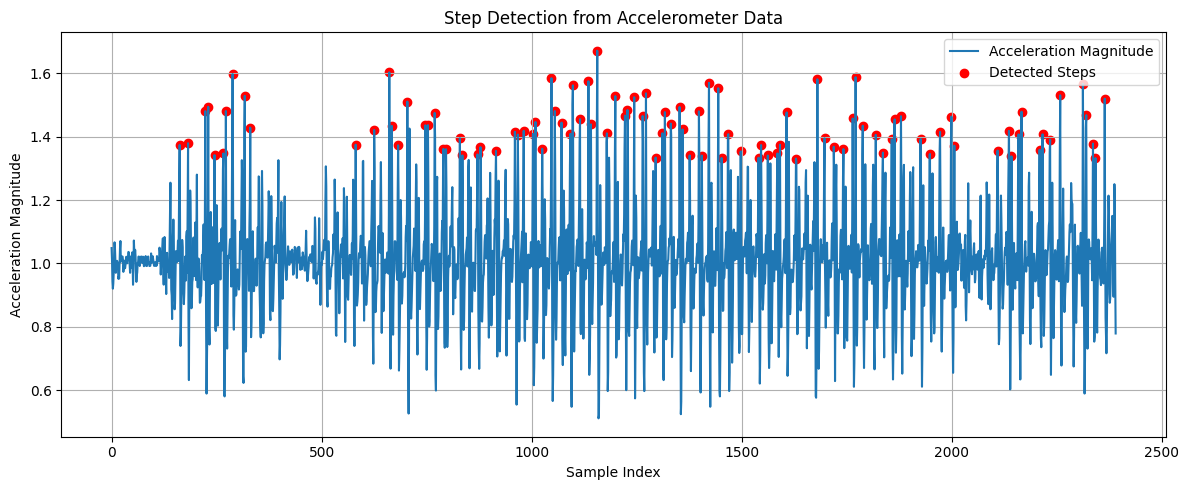

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_data(file_path):
    """Load CSV file and compute acceleration magnitude."""
    df = pd.read_csv(file_path)

    if {'ax', 'ay', 'az'}.issubset(df.columns):
        df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
    else:
        raise ValueError("CSV must contain 'ax', 'ay', and 'az' columns.")
    
    return df

def detect_steps(acc_data, threshold=1.05, min_interval=5):
    """Detect steps using peak detection."""
    step_indices = []
    last_index = -np.inf

    for i in range(1, len(acc_data) - 1):
        if acc_data[i] > threshold and acc_data[i] > acc_data[i - 1] and acc_data[i] > acc_data[i + 1]:
            if i - last_index > min_interval:
                step_indices.append(i)
                last_index = i
    return step_indices

def plot_steps(acc_mag, step_indices):
    """Plot acceleration magnitude and detected steps."""
    plt.figure(figsize=(12, 5))
    plt.plot(acc_mag, label='Acceleration Magnitude')
    plt.scatter(step_indices, acc_mag[step_indices], color='red', label='Detected Steps')
    plt.title('Step Detection from Accelerometer Data')
    plt.xlabel('Sample Index')
    plt.ylabel('Acceleration Magnitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def main():
    #  USER CONFIGURATION 
    file_path = "test2.csv"    
    threshold = 1.33          
    min_interval = 5           

    df = load_data(file_path)
    acc_mag = df['acc_mag'].values
    step_indices = detect_steps(acc_mag, threshold, min_interval)

    print(f"Total steps detected: {len(step_indices)}")
    plot_steps(acc_mag, step_indices)

if __name__ == "__main__":
    main()


### Heading Estimation

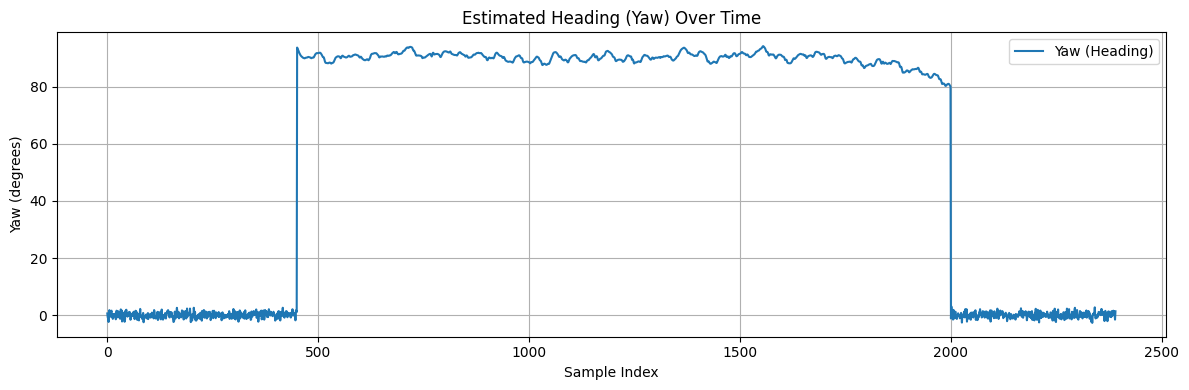

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV File
csv_file = "test2.csv"  
df = pd.read_csv(csv_file)

# Clean column names
df.columns = df.columns.str.strip()

# Plot Yaw
plt.figure(figsize=(12, 4))
plt.plot(df["yaw"], label="Yaw (Heading)", color='tab:blue')
plt.title("Estimated Heading (Yaw) Over Time")
plt.xlabel("Sample Index")
plt.ylabel("Yaw (degrees)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Step count and Heading path


- **Acceleration Magnitude Calculation**  
  Approach consistent with [pavloshargan/accelerometer_step_counter](https://github.com/pavloshargan/accelerometer_step_counter) — MIT License  
 


Found 96 steps. Reconstructing path...


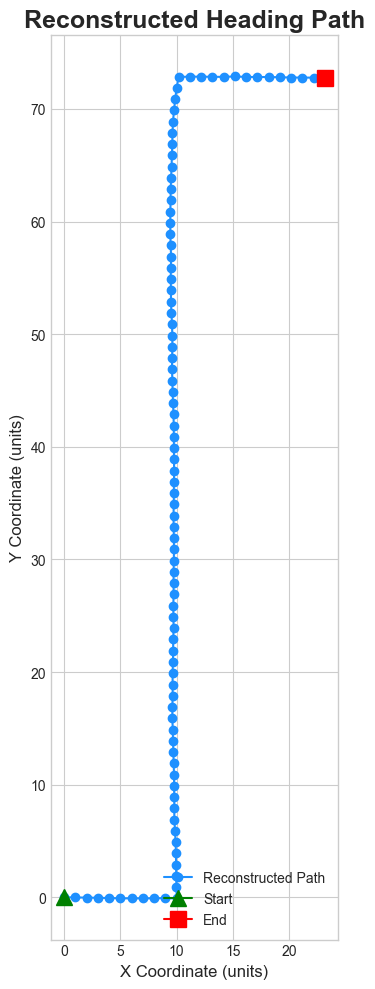

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Configuration
CSV_FILE_PATH = 'test2.csv'

# Step Detection Parameters
STEP_THRESHOLD = 1.34
MIN_STEP_DISTANCE = 4
STEP_LENGTH = 1.0  # Assume each step covers a distance of 1.0 unit

# Main Script

# 1. Load the dataset
try:
    df = pd.read_csv(CSV_FILE_PATH)
except FileNotFoundError:
    print(f"Error: The file '{CSV_FILE_PATH}' was not found.")
    exit()

# 2. Prepare data and detect steps
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['acc_magnitude'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
step_indices, _ = find_peaks(
    df['acc_magnitude'],
    height=STEP_THRESHOLD,
    distance=MIN_STEP_DISTANCE
)
total_steps = len(step_indices)
print(f"Found {total_steps} steps. Reconstructing path...")

# 3. Reconstruct the path using heading (yaw) at each step
path_x = [0]
path_y = [0]

for i in range(total_steps):
    # Get the yaw value at the moment of the step
    # Note: We convert yaw from degrees to radians for trigonometric functions
    current_yaw_rad = np.deg2rad(df['yaw'].iloc[step_indices[i]])

    # Calculate the change in x and y based on the heading
    # Assumes a fixed step length for each step
    delta_x = STEP_LENGTH * np.cos(current_yaw_rad)
    delta_y = STEP_LENGTH * np.sin(current_yaw_rad)

    # Append the new coordinates to the path
    path_x.append(path_x[-1] + delta_x)
    path_y.append(path_y[-1] + delta_y)

# 4. Visualize the heading path
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the reconstructed path
ax.plot(path_x, path_y, marker='o', linestyle='-', color='dodgerblue', label='Reconstructed Path')

# Mark the start and end points for clarity
ax.plot(path_x[0], path_y[0], marker='^', markersize=12, color='green', label='Start')
ax.plot(path_x[-1], path_y[-1], marker='s', markersize=12, color='red', label='End')

# Formatting the plot
ax.set_title('Reconstructed Heading Path', fontsize=18, fontweight='bold')
ax.set_xlabel('X Coordinate (units)', fontsize=12)
ax.set_ylabel('Y Coordinate (units)', fontsize=12)
ax.legend()
ax.grid(True)
ax.set_aspect('equal', adjustable='box') # Ensures the path is not stretched
plt.tight_layout()
plt.show()

## Plot the recoreded data on map

In [1]:
import pygame
import numpy as np

# Parameters
CELL_PX = 18
WIDTH = 18   # columns
HEIGHT = 45  # rows

# Colors
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
BLUE  = (0, 0, 255)
RED   = (255, 0, 0)
CYAN  = (0, 200, 255)  

# Floor Map
def build_floor_map():
    fmap = np.zeros((HEIGHT, WIDTH), dtype=int)
    fmap[0:4,   0:8]  = 1   # Bottom horizontal part
    fmap[0:4,   0:6]  = 1   # Left extension (partially overlaps with the above)
    fmap[4:39,  5:8]  = 1   # Vertical corridor
    fmap[39:41, 5:14] = 1   # Top corridor
    return fmap

# Path Construction
def interpolate_path(start, end, step_length):
    dx = end[0] - start[0]
    dy = end[1] - start[1]
    # Use the larger of dx or dy to determine the distance for interpolation
    dist = max(abs(dx), abs(dy))
    if dist == 0:
        return [start]
    steps = int(dist / step_length)
    if steps == 0:
        return [start, end]
    path = []
    for i in range(steps + 1):
        t = i / steps
        x = start[0] + t * dx
        y = start[1] + t * dy
        path.append((x, y))
    return path

def build_heading_path():
    """
    Builds the complete path by connecting segments.
    """
    path = []
    # Segment 1: Bottom Horizontal (from (0,1) to (7,1))
    path += interpolate_path((0, 1), (7, 1), 0.615)

    # Segment 2: Vertical (from (7,1) to (7,40))
    path += interpolate_path((7, 1), (7, 40), 0.5)

    # Segment 3: Top Horizontal (from (7,40) to (13,40))
    path += interpolate_path((7, 40), (13, 40), 0.615)

    return path

# Main Drawing
def draw_map(screen, fmap, start, end, beacons, heading_path):
    """
    Draws the entire scene, including the map outline, points, and the dynamic path.
    """
    screen.fill(WHITE)  # Full background is white

    # Draw only the walls (borders between floor and non-floor)
    for y in range(HEIGHT):
        for x in range(WIDTH):
            if fmap[y, x] == 1:  # This is a floor cell
                screen_x = x * CELL_PX
                screen_y = (HEIGHT - 1 - y) * CELL_PX
                # Check and draw walls only at the boundaries of the floor shape
                if y + 1 >= HEIGHT or fmap[y + 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x + CELL_PX, screen_y), 2)
                if y - 1 < 0 or fmap[y - 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y + CELL_PX), (screen_x + CELL_PX, screen_y + CELL_PX), 2)
                if x + 1 >= WIDTH or fmap[y, x + 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x + CELL_PX, screen_y), (screen_x + CELL_PX, screen_y + CELL_PX), 2)
                if x - 1 < 0 or fmap[y, x - 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x, screen_y + CELL_PX), 2)

    # Draw Start and End points
    sx, sy = start
    ex, ey = end
    pygame.draw.circle(screen, BLUE, (int(sx * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - sy) * CELL_PX + CELL_PX / 2)), 6)
    pygame.draw.circle(screen, BLUE, (int(ex * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - ey) * CELL_PX + CELL_PX / 2)), 6)

    # Draw Beacons with labels
    font = pygame.font.SysFont('Arial', 12)
    for label, (bx, by) in beacons.items():
        cx = int(bx * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - by) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, RED, (cx, cy), 6)
        text = font.render(label, True, RED)
        screen.blit(text, (cx + 5, cy - 5))

    # Draw the animated heading path
    for x, y in heading_path:
        cx = x * CELL_PX + CELL_PX / 2
        cy = (HEIGHT - 1 - y) * CELL_PX + CELL_PX / 2
        pygame.draw.circle(screen, CYAN, (int(cx), int(cy)), 4)

    pygame.display.flip()

# Pygame App
def main():
    """
    Initializes Pygame and runs the main application loop with path animation.
    """
    pygame.init()
    screen = pygame.display.set_mode((WIDTH * CELL_PX, HEIGHT * CELL_PX))
    pygame.display.set_caption("L-Shaped Floor Plan with Step-by-Step Path")

    fmap = build_floor_map()
    start = (0, 1)
    end = (13, 40)
    beacons = {
        "B₁": (3, 0),
        "B₂": (7, 11),
        "B₃": (5, 30),
        "B₄": (9, 39)
    }

    heading_path = build_heading_path()
    step_index = 0

    clock = pygame.time.Clock()
    running = True
    while running:
        # Animate the path by revealing one more step each frame
        if step_index < len(heading_path):
            step_index += 1

        # Only draw the steps up to the current index
        current_path = heading_path[:step_index]

        draw_map(screen, fmap, start, end, beacons, current_path)
        clock.tick(10)  # Control animation speed to 10 frames per second

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

    pygame.quit()

# Run
if __name__ == "__main__":
    main()


pygame 2.6.1 (SDL 2.28.4, Python 3.11.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Particle filter

### Particle filter without resampling

>  **Citations & Reference Notes:**
>
>  This script was partially generated with the assistance of OpenAI's ChatGPT (2025).
>
> - **Visualization with Pygame**:  
>   The visual animation using `pygame`, layered particle paths, and heading visualization builds on standard game loop structures and rendering patterns available in:
>   - [pygame/examples](https://github.com/pygame/pygame/tree/main/examples)
>   - OpenCV integration for video recording is based on:
>     - [OpenCV VideoWriter Docs](https://docs.opencv.org/4.x/dd/d9e/classcv_1_1VideoWriter.html)  
>     - [pygame screen capture to OpenCV](https://stackoverflow.com/a/61644326)
>



In [2]:
import pygame
import numpy as np
import random
import cv2  # OpenCV for recording

# Parameters
CELL_PX = 18
WIDTH = 18   # columns
HEIGHT = 45  # rows

# Colors
WHITE  = (255, 255, 255)
BLACK  = (0, 0, 0)
BLUE   = (0, 0, 255)
RED    = (255, 0, 0)
CYAN   = (0, 200, 255)  # Heading path
PURPLE = (160, 32, 240)  # Particle color

# Particle Filter Parameters
NUM_PARTICLES = 200
STEP_NOISE = 0.2

# Floor Map
def build_floor_map():
    fmap = np.zeros((HEIGHT, WIDTH), dtype=int)
    fmap[0:4,   0:8]  = 1   # Bottom horizontal part
    fmap[0:4,   0:6]  = 1   # Left extension
    fmap[4:39,  5:8]  = 1   # Vertical corridor
    fmap[39:41, 5:14] = 1   # Top corridor
    return fmap

# Path Construction
def interpolate_path(start, end, step_length):
    dx = end[0] - start[0]
    dy = end[1] - start[1]
    dist = max(abs(dx), abs(dy))
    if dist == 0:
        return [start]
    steps = int(dist / step_length)
    if steps == 0:
        return [start, end]
    path = []
    for i in range(steps + 1):
        t = i / steps
        x = start[0] + t * dx
        y = start[1] + t * dy
        path.append((x, y))
    return path

def build_heading_path():
    path = []
    path += interpolate_path((0, 1), (7, 1), 0.615)
    path += interpolate_path((7, 1), (7, 40), 0.5)
    path += interpolate_path((7, 40), (13, 40), 0.615)
    return path

# Particle Filter
def distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def initialize_particles(fmap, num_particles):
    valid_positions = [(x, y)
                       for y in range(HEIGHT)
                       for x in range(WIDTH)
                       if fmap[y, x] == 1]
    particles = random.choices(valid_positions, k=num_particles)
    return [(float(x), float(y)) for x, y in particles]

def motion_update(particles, dx, dy):
    updated = []
    for x, y in particles:
        nx = x + dx + random.gauss(0, STEP_NOISE)
        ny = y + dy + random.gauss(0, STEP_NOISE)
        updated.append((nx, ny))
    return updated

def compute_weights(particles, beacon_pos):
    weights = []
    for x, y in particles:
        dist = distance((x, y), beacon_pos)
        weight = np.exp(-dist ** 2 / 2.0)
        weights.append(weight)
    total = sum(weights)
    if total == 0:
        return [1.0 / len(particles)] * len(particles)
    return [w / total for w in weights]

def resample(particles, weights):
    indices = np.random.choice(range(len(particles)), size=len(particles), p=weights)
    return [particles[i] for i in indices]

# Drawing
def draw_map(screen, fmap, start, end, beacons, heading_path, particles, record_video=False, video_writer=None):
    screen.fill(WHITE)

    # Walls
    for y in range(HEIGHT):
        for x in range(WIDTH):
            if fmap[y, x] == 1:
                screen_x = x * CELL_PX
                screen_y = (HEIGHT - 1 - y) * CELL_PX
                if y + 1 >= HEIGHT or fmap[y + 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x + CELL_PX, screen_y), 2)
                if y - 1 < 0 or fmap[y - 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y + CELL_PX), (screen_x + CELL_PX, screen_y + CELL_PX), 2)
                if x + 1 >= WIDTH or fmap[y, x + 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x + CELL_PX, screen_y), (screen_x + CELL_PX, screen_y + CELL_PX), 2)
                if x - 1 < 0 or fmap[y, x - 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x, screen_y + CELL_PX), 2)

    # Start and End
    sx, sy = start
    ex, ey = end
    pygame.draw.circle(screen, BLUE, (int(sx * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - sy) * CELL_PX + CELL_PX / 2)), 6)
    pygame.draw.circle(screen, BLUE, (int(ex * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - ey) * CELL_PX + CELL_PX / 2)), 6)

    # Beacons
    for label, (bx, by) in beacons.items():
        cx = int(bx * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - by) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, RED, (cx, cy), 6)

    # Heading path
    for x, y in heading_path:
        cx = int(x * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - y) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, CYAN, (cx, cy), 3)

    # Particles
    for x, y in particles:
        cx = int(x * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - y) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, PURPLE, (cx, cy), 2)

    pygame.display.flip()

    # Capture frame
    if record_video and video_writer is not None:
        frame = pygame.surfarray.array3d(screen)
        frame = np.transpose(frame, (1, 0, 2))  # Convert to (H, W, C)
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        video_writer.write(frame)

# Main
def main():
    pygame.init()
    screen = pygame.display.set_mode((WIDTH * CELL_PX, HEIGHT * CELL_PX))
    pygame.display.set_caption("L-Shaped Floor Plan with Particle Filter")

    # Video Recording Setup
    record_video = True
    video_writer = None
    if record_video:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        frame_size = (WIDTH * CELL_PX, HEIGHT * CELL_PX)
        video_writer = cv2.VideoWriter("particle_filter_output_without_resamping.mp4", fourcc, 10, frame_size)
        
    fmap = build_floor_map()
    start = (0, 1)
    end   = (13, 40)
    beacons = {
        "B₁": (3, 0),
        "B₂": (7, 11),
        "B₃": (5, 30),
        "B₄": (9, 39)
    }

    heading_path = build_heading_path()
    particles = initialize_particles(fmap, NUM_PARTICLES)

    clock = pygame.time.Clock()
    step_idx = 1

    running = True
    while running:
        if step_idx < len(heading_path):
            prev = heading_path[step_idx - 1]
            curr = heading_path[step_idx]
            dx, dy = curr[0] - prev[0], curr[1] - prev[1]

            # Predict
            particles = motion_update(particles, dx, dy)

            # Update
            for label, bpos in beacons.items():
                if distance(curr, bpos) < 4:
                    weights = compute_weights(particles, bpos)
                    particles = resample(particles, weights)
                    break

            step_idx += 1

        draw_map(screen, fmap, start, end, beacons, heading_path[:step_idx], particles, record_video, video_writer)
        clock.tick(10)

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

    #  Finish recording
    if record_video and video_writer is not None:
        video_writer.release()

    pygame.quit()

# Run
if __name__ == "__main__":
    main()


## Implementation of Particle Filter with Map-Based Particle Elimination and Resampling

>  This script was partially generated with the assistance of OpenAI's ChatGPT (2025).

In [ ]:
import pygame
import numpy as np
import random
import cv2  # For video recording

# Parameters
CELL_PX = 18
WIDTH = 18   # columns
HEIGHT = 45  # rows

# Colors
WHITE  = (255, 255, 255)
BLACK  = (0, 0, 0)
BLUE   = (0, 0, 255)
RED    = (255, 0, 0)
CYAN   = (0, 200, 255)  # Heading path
PURPLE = (160, 32, 240)  # Particle color

# Particle Filter Parameters
NUM_PARTICLES = 200
STEP_NOISE = 0.2

# Floor Map
def build_floor_map():
    """
    Builds the L-shaped floor map using a numpy array.
    1 represents a walkable floor cell, 0 represents a wall or non-space.
    """
    fmap = np.zeros((HEIGHT, WIDTH), dtype=int)
    fmap[0:4,   0:8]  = 1   # Bottom horizontal part
    fmap[0:4,   0:6]  = 1   # Left extension
    fmap[4:39,  5:8]  = 1   # Vertical corridor
    fmap[39:41, 5:14] = 1   # Top corridor
    return fmap

# Precompute valid floor cells (helps for fast resampling)
def list_valid_positions(fmap):
    return [(x, y)
            for y in range(HEIGHT)
            for x in range(WIDTH)
            if fmap[y, x] == 1]

# Path Construction
def interpolate_path(start, end, step_length):
    """
    Generates a list of points between a start and end coordinate.
    """
    dx = end[0] - start[0]
    dy = end[1] - start[1]
    dist = max(abs(dx), abs(dy))
    if dist == 0:
        return [start]
    steps = int(dist / step_length)
    if steps == 0:
        return [start, end]
    path = []
    for i in range(steps + 1):
        t = i / steps
        x = start[0] + t * dx
        y = start[1] + t * dy
        path.append((x, y))
    return path

def build_heading_path():
    path = []
    path += interpolate_path((0, 1), (7, 1), 0.615)
    path += interpolate_path((7, 1), (7, 40), 0.5)
    path += interpolate_path((7, 40), (13, 40), 0.615)
    return path

# Utility Functions for Particle Filter
def distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def initialize_particles(fmap, num_particles):
    valid_positions = list_valid_positions(fmap)
    particles = random.choices(valid_positions, k=num_particles)
    return [(float(x), float(y)) for x, y in particles]

def is_valid_particle(x, y, fmap):
    mx = int(round(x))
    my = int(round(y))
    if mx < 0 or mx >= WIDTH or my < 0 or my >= HEIGHT:
        return False
    return fmap[my, mx] == 1

def enforce_valid_particles(particles, fmap):
    valid = [p for p in particles if is_valid_particle(p[0], p[1], fmap)]
    invalid_count = len(particles) - len(valid)

    if invalid_count <= 0:
        return particles  

    if not valid:
        # Catastrophic: all invalid. Reinitialize uniformly on floor cells.
        return initialize_particles(fmap, len(particles))

    # Resample invalid from current valid set (with replacement).
    replacements = random.choices(valid, k=invalid_count)
    return valid + replacements

def motion_update(particles, dx, dy, fmap):
    updated = []
    for x, y in particles:
        nx = x + dx + random.gauss(0, STEP_NOISE)
        ny = y + dy + random.gauss(0, STEP_NOISE)
        updated.append((nx, ny))
    # Repair any particles that moved through walls
    return enforce_valid_particles(updated, fmap)

def compute_weights(particles, beacon_pos):
    weights = []
    for x, y in particles:
        dist = distance((x, y), beacon_pos)
        weight = np.exp(-dist ** 2 / 2.0)  # Gaussian weight
        weights.append(weight)
    total = sum(weights)
    if total == 0:
        return [1.0 / len(particles)] * len(particles) # Avoid division by zero
    return [w / total for w in weights]

def resample(particles, weights):
    indices = np.random.choice(range(len(particles)), size=len(particles), p=weights)
    return [particles[i] for i in indices]

# Drawing
def draw_map(screen, fmap, start, end, beacons, heading_path, particles,
             record_video=False, video_writer=None):
    screen.fill(WHITE) # Background is white

    # Draw only the walls (borders between floor and non-floor)
    for y in range(HEIGHT):
        for x in range(WIDTH):
            if fmap[y, x] == 1:  
                screen_x = x * CELL_PX
                screen_y = (HEIGHT - 1 - y) * CELL_PX
                if y + 1 >= HEIGHT or fmap[y + 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x + CELL_PX, screen_y), 2)
                if y - 1 < 0 or fmap[y - 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y + CELL_PX), (screen_x + CELL_PX, screen_y + CELL_PX), 2)
                if x + 1 >= WIDTH or fmap[y, x + 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x + CELL_PX, screen_y), (screen_x + CELL_PX, screen_y + CELL_PX), 2)
                if x - 1 < 0 or fmap[y, x - 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x, screen_y + CELL_PX), 2)

    # Start and End points
    sx, sy = start
    ex, ey = end
    pygame.draw.circle(screen, BLUE, (int(sx * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - sy) * CELL_PX + CELL_PX / 2)), 6)
    pygame.draw.circle(screen, BLUE, (int(ex * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - ey) * CELL_PX + CELL_PX / 2)), 6)

    # Beacons
    for label, (bx, by) in beacons.items():
        cx = int(bx * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - by) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, RED, (cx, cy), 6)

    # Heading path traveled 
    for x, y in heading_path:
        cx = int(x * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - y) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, CYAN, (cx, cy), 3)

    # Particles
    for x, y in particles:
        cx = int(x * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - y) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, PURPLE, (cx, cy), 2)

    pygame.display.flip()

    # Capture frame for video
    if record_video and video_writer is not None:
        frame = pygame.surfarray.array3d(screen)          # (W, H, 3), RGB
        frame = np.transpose(frame, (1, 0, 2))            # -> (H, W, 3)
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)    # OpenCV expects BGR
        video_writer.write(frame)

# Main App
def main():
    pygame.init()
    screen = pygame.display.set_mode((WIDTH * CELL_PX, HEIGHT * CELL_PX))
    pygame.display.set_caption("L-Shaped Floor Plan with Particle Filter")

    # Video Recording Setup
    record_video = True  # set False to disable
    video_writer = None
    if record_video:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # MP4-friendly codec
        frame_size = (WIDTH * CELL_PX, HEIGHT * CELL_PX)
        video_writer = cv2.VideoWriter("particle_filter_final_output.mp4", fourcc, 10, frame_size)

    fmap = build_floor_map()
    valid_positions_cache = list_valid_positions(fmap)  
    start = (0, 1)
    end   = (13, 40)
    beacons = {
        "B₁": (3, 0),
        "B₂": (7, 11),
        "B₃": (5, 30),
        "B₄": (9, 39)
    }

    heading_path = build_heading_path()
    particles = initialize_particles(fmap, NUM_PARTICLES)

    clock = pygame.time.Clock()
    step_idx = 1

    running = True
    while running:
        if step_idx < len(heading_path):
            prev = heading_path[step_idx - 1]
            curr = heading_path[step_idx]
            dx, dy = curr[0] - prev[0], curr[1] - prev[1]

            # Predict: move and repair invalids
            particles = motion_update(particles, dx, dy, fmap)

            # Update: When near a beacon, re-weight and resample
            for label, bpos in beacons.items():
                if distance(curr, bpos) < 4:  # Beacon detection radius
                    weights = compute_weights(particles, bpos)
                    particles = resample(particles, weights)
                    # Enforce validity again after measurement resample
                    particles = enforce_valid_particles(particles, fmap)
                    break  # Only update for one beacon at a time

            step_idx += 1

        # Draw the current state (and optionally record)
        draw_map(screen, fmap, start, end, beacons, heading_path[:step_idx], particles,
                 record_video=record_video, video_writer=video_writer)
        clock.tick(10)  # simulation FPS

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

    # Finish recording
    if record_video and video_writer is not None:
        video_writer.release()

    pygame.quit()

# Run
if __name__ == "__main__":
    main()


## Analysis of localization accuracy under varying configurations (e.g., with/without map, with/without RSSI)

### 1. With RSSI and With Map

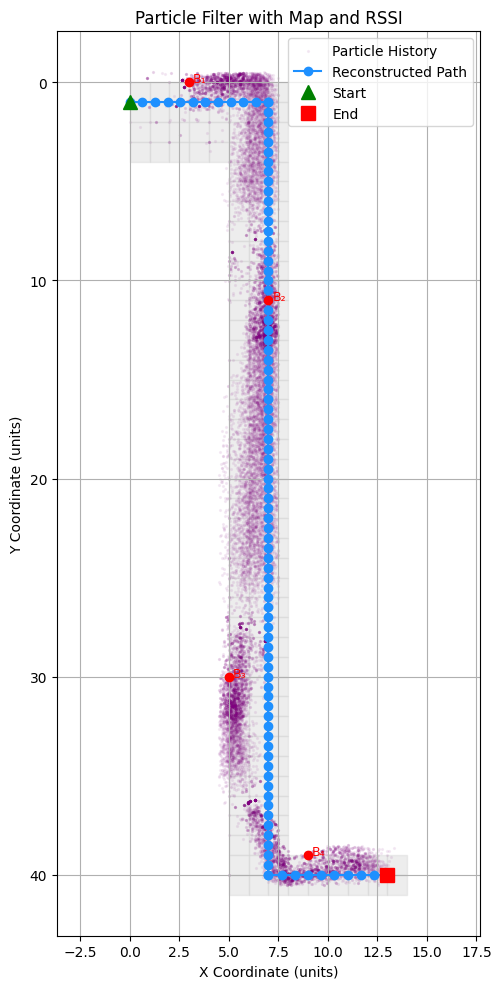

In [4]:
import pygame
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt

# Parameters
CELL_PX = 18
WIDTH = 18
HEIGHT = 45

WHITE  = (255, 255, 255)
BLACK  = (0, 0, 0)
BLUE   = (0, 0, 255)
RED    = (255, 0, 0)
CYAN   = (0, 200, 255)
PURPLE = (160, 32, 240)

NUM_PARTICLES = 200
STEP_NOISE = 0.2

# Floor Map
def build_floor_map():
    fmap = np.zeros((HEIGHT, WIDTH), dtype=int)
    fmap[0:4,   0:8]  = 1
    fmap[0:4,   0:6]  = 1
    fmap[4:39,  5:8]  = 1
    fmap[39:41, 5:14] = 1
    return fmap

def list_valid_positions(fmap):
    return [(x, y)
            for y in range(HEIGHT)
            for x in range(WIDTH)
            if fmap[y, x] == 1]

# Path Construction
def interpolate_path(start, end, step_length):
    dx = end[0] - start[0]
    dy = end[1] - start[1]
    dist = max(abs(dx), abs(dy))
    if dist == 0:
        return [start]
    steps = int(dist / step_length)
    return [(start[0] + (i/steps)*dx, start[1] + (i/steps)*dy) for i in range(steps + 1)]

def build_heading_path():
    path = []
    path += interpolate_path((0, 1), (7, 1), 0.615)
    path += interpolate_path((7, 1), (7, 40), 0.5)
    path += interpolate_path((7, 40), (13, 40), 0.615)
    return path

# Particle Filter Utils
def distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def initialize_particles(fmap, num_particles):
    valid_positions = list_valid_positions(fmap)
    particles = random.choices(valid_positions, k=num_particles)
    return [(float(x), float(y)) for x, y in particles]

def is_valid_particle(x, y, fmap):
    mx, my = int(round(x)), int(round(y))
    if mx < 0 or mx >= WIDTH or my < 0 or my >= HEIGHT:
        return False
    return fmap[my, mx] == 1

def enforce_valid_particles(particles, fmap):
    valid = [p for p in particles if is_valid_particle(p[0], p[1], fmap)]
    invalid_count = len(particles) - len(valid)
    if invalid_count <= 0:
        return particles
    if not valid:
        return initialize_particles(fmap, len(particles))
    replacements = random.choices(valid, k=invalid_count)
    return valid + replacements

def motion_update(particles, dx, dy, fmap):
    updated = [(x + dx + random.gauss(0, STEP_NOISE),
                y + dy + random.gauss(0, STEP_NOISE)) for x, y in particles]
    return enforce_valid_particles(updated, fmap)

def compute_weights(particles, beacon_pos):
    weights = []
    for x, y in particles:
        dist = distance((x, y), beacon_pos)
        weights.append(np.exp(-dist ** 2 / 2.0))
    total = sum(weights)
    return [w / total for w in weights] if total > 0 else [1.0 / len(particles)] * len(particles)

def resample(particles, weights):
    indices = np.random.choice(range(len(particles)), size=len(particles), p=weights)
    return [particles[i] for i in indices]

# Drawing
def draw_map(screen, fmap, start, end, beacons, heading_path, particles,
             record_video=False, video_writer=None):
    screen.fill(WHITE)
    for y in range(HEIGHT):
        for x in range(WIDTH):
            if fmap[y, x] == 1:
                screen_x = x * CELL_PX
                screen_y = (HEIGHT - 1 - y) * CELL_PX
                if y + 1 >= HEIGHT or fmap[y + 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x + CELL_PX, screen_y), 2)
                if y - 1 < 0 or fmap[y - 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y + CELL_PX), (screen_x + CELL_PX, screen_y + CELL_PX), 2)
                if x + 1 >= WIDTH or fmap[y, x + 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x + CELL_PX, screen_y), (screen_x + CELL_PX, screen_y + CELL_PX), 2)
                if x - 1 < 0 or fmap[y, x - 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x, screen_y + CELL_PX), 2)

    # Start, End
    sx, sy = start
    ex, ey = end
    pygame.draw.circle(screen, BLUE, (int(sx * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - sy) * CELL_PX + CELL_PX / 2)), 6)
    pygame.draw.circle(screen, BLUE, (int(ex * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - ey) * CELL_PX + CELL_PX / 2)), 6)

    # Beacons
    for (bx, by) in beacons.values():
        cx = int(bx * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - by) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, RED, (cx, cy), 6)

    # Heading path
    for x, y in heading_path:
        cx = int(x * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - y) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, CYAN, (cx, cy), 3)

    # Particles
    for x, y in particles:
        cx = int(x * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - y) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, PURPLE, (cx, cy), 2)

    pygame.display.flip()

    if record_video and video_writer is not None:
        frame = pygame.surfarray.array3d(screen)
        frame = np.transpose(frame, (1, 0, 2))
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        video_writer.write(frame)

# Final Particle Trail Plot
def plot_particle_history(fmap, heading_path, particle_history, beacons):
    all_x, all_y = [], []
    for frame in particle_history:
        xs, ys = zip(*frame)
        all_x.extend(xs)
        all_y.extend(ys)

    path_x, path_y = zip(*heading_path)

    plt.figure(figsize=(5, 10))

    # Floor plan
    for y in range(HEIGHT):
        for x in range(WIDTH):
            if fmap[y, x] == 1:
                plt.gca().add_patch(plt.Rectangle((x, y), 1, 1, color='lightgray', alpha=0.4))

    # Particle trail
    plt.scatter(all_x, all_y, s=2, color='purple', alpha=0.06, label="Particle History")

    # Path
    plt.plot(path_x, path_y, 'o-', color='dodgerblue', label="Reconstructed Path")

    # Beacons
    for label, (bx, by) in beacons.items():
        plt.plot(bx, by, 'ro')
        plt.text(bx + 0.2, by, label, color='red', fontsize=9)

    # Start / End
    plt.plot(path_x[0], path_y[0], 'g^', markersize=10, label='Start')
    plt.plot(path_x[-1], path_y[-1], 'rs', markersize=10, label='End')

    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.title("Particle Filter with Map and RSSI")
    plt.xlabel("X Coordinate (units)")
    plt.ylabel("Y Coordinate (units)")
    plt.tight_layout()
    plt.show()

# Main
def main():
    pygame.init()
    screen = pygame.display.set_mode((WIDTH * CELL_PX, HEIGHT * CELL_PX))
    pygame.display.set_caption("Particle Filter with Map and RSSI")

    record_video = True
    video_writer = None
    if record_video:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        frame_size = (WIDTH * CELL_PX, HEIGHT * CELL_PX)
        video_writer = cv2.VideoWriter("particle_filter_with_map_with_RSSI.mp4", fourcc, 10, frame_size)

    fmap = build_floor_map()
    heading_path = build_heading_path()
    start, end = (0, 1), (13, 40)
    beacons = {
        "B₁": (3, 0),
        "B₂": (7, 11),
        "B₃": (5, 30),
        "B₄": (9, 39)
    }

    particles = initialize_particles(fmap, NUM_PARTICLES)
    particle_history = [particles.copy()]

    step_idx = 1
    clock = pygame.time.Clock()
    running = True

    while running:
        if step_idx < len(heading_path):
            prev = heading_path[step_idx - 1]
            curr = heading_path[step_idx]
            dx, dy = curr[0] - prev[0], curr[1] - prev[1]

            particles = motion_update(particles, dx, dy, fmap)

            for label, bpos in beacons.items():
                if distance(curr, bpos) < 4:
                    weights = compute_weights(particles, bpos)
                    particles = resample(particles, weights)
                    particles = enforce_valid_particles(particles, fmap)
                    break

            particle_history.append(particles.copy())
            step_idx += 1

        draw_map(screen, fmap, start, end, beacons, heading_path[:step_idx], particles,
                 record_video=record_video, video_writer=video_writer)

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
        clock.tick(10)

    if record_video and video_writer is not None:
        video_writer.release()
    pygame.quit()

    # Final particle history plot
    plot_particle_history(fmap, heading_path[:step_idx], particle_history, beacons)


if __name__ == "__main__":
    main()


### 2. With RSSI and without map

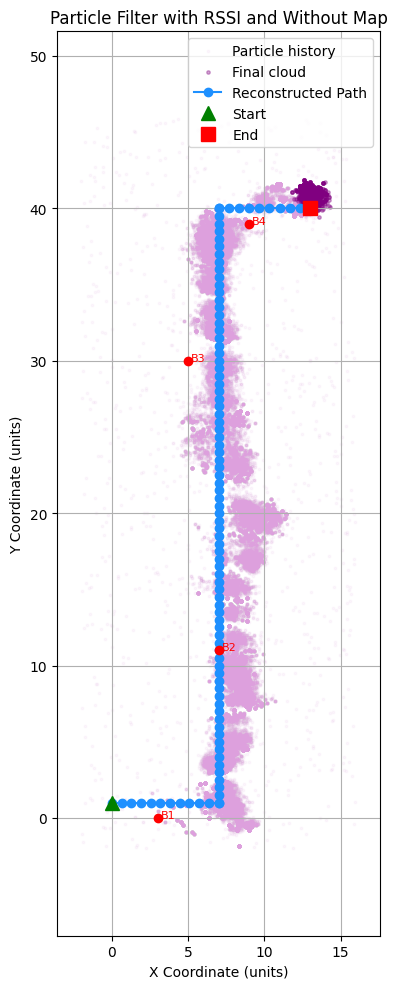

In [13]:
import pygame
import numpy as np
import random
import cv2               
import matplotlib.pyplot as plt

# Visualisation
CELL_PX   = 18            # pixel size of one "unit"
MIN_X, MAX_X = -2, 16     # bounding box covering the walk
MIN_Y, MAX_Y = -2, 46

SCREEN_W = int((MAX_X - MIN_X + 1) * CELL_PX)
SCREEN_H = int((MAX_Y - MIN_Y + 1) * CELL_PX)

# Pygame colours
WHITE  = (255, 255, 255)
BLUE   = (0, 0, 255)
CYAN   = (0, 200, 255)
RED    = (255, 0, 0)
PURPLE = (160, 32, 240)

# Particle Filter
NUM_PARTICLES = 1000
STEP_NOISE    = 0.30      # motion noise (units)

# RSSI model
TX_POWER      = -59       # RSSI at 1 m (dBm)
PATH_LOSS_EXP = 2.0       # path‑loss exponent
MEAS_SIGMA    = 1.0       # distance noise (m)

# Simulation options
ADD_RSSI_NOISE = True
RSSI_NOISE_STD = 2.0       # dBm

RECORD_VIDEO   = True
VIDEO_FILE     = "particle_filter_with_RSSI_Without_map00000.mp4"
FPS            = 10

# HELPER FUNCTION

def interpolate_path(start, end, step_len):
    dx, dy = end[0] - start[0], end[1] - start[1]
    dist   = max(abs(dx), abs(dy))
    if dist == 0:
        return [start]
    steps  = int(dist / step_len)
    return [(start[0] + (i/steps)*dx, start[1] + (i/steps)*dy) for i in range(steps + 1)]

def build_heading_path():
    p  = interpolate_path((0, 1),  (7, 1),  0.615)
    p += interpolate_path((7, 1),  (7, 40), 0.50)
    p += interpolate_path((7, 40), (13, 40), 0.615)
    return p

# RSSI helpers
def rssi_to_distance(rssi):
    return 10 ** ((TX_POWER - rssi) / (10 * PATH_LOSS_EXP))

def distance_to_rssi(d):
    if d <= 0: d = 0.01
    return TX_POWER - 10 * PATH_LOSS_EXP * np.log10(d)

# Particle filter helpers
def distance(p1, p2):
    return np.linalg.norm(np.subtract(p1, p2))

def initialize_particles(n):
    xs = np.random.uniform(MIN_X, MAX_X, size=n)
    ys = np.random.uniform(MIN_Y, MAX_Y, size=n)
    return list(zip(xs, ys))

def motion_update(particles, dx, dy):
    return [(x + dx + random.gauss(0, STEP_NOISE),
             y + dy + random.gauss(0, STEP_NOISE)) for (x, y) in particles]

def compute_weights_rssi(particles, rssi_dict, beacons):
    w = np.ones(len(particles))
    for label, rssi in rssi_dict.items():
        d_meas = rssi_to_distance(rssi)
        bx, by = beacons[label]
        for i, (px, py) in enumerate(particles):
            d_pred = distance((px, py), (bx, by))
            w[i]  *= np.exp(-0.5 * ((d_pred - d_meas) / MEAS_SIGMA) ** 2)
    s = np.sum(w)
    return w / s if s > 0 else np.ones(len(particles))/len(particles)

def resample(particles, weights):
    idx = np.random.choice(len(particles), size=len(particles), p=weights)
    return [particles[i] for i in idx]

def simulate_rssi(true_pos, beacons):
    dists = {label: distance(true_pos, bpos) for label, bpos in beacons.items()}
    readings = {}
    for label, d in dists.items():
        rssi = distance_to_rssi(d)
        if ADD_RSSI_NOISE:
            rssi += np.random.normal(0.0, RSSI_NOISE_STD)
        readings[label] = rssi
    return readings

# Pygame drawing
def world_to_screen(x, y):
    return int((x - MIN_X) * CELL_PX), int((MAX_Y - y) * CELL_PX)

def draw_scene(screen, heading_so_far, particles, beacons):
    screen.fill(WHITE)
    for x, y in heading_so_far:
        pygame.draw.circle(screen, CYAN, world_to_screen(x, y), 3)
    for x, y in particles:
        pygame.draw.circle(screen, PURPLE, world_to_screen(x, y), 2)
    for (bx, by) in beacons.values():
        pygame.draw.circle(screen, RED, world_to_screen(bx, by), 6)
    pygame.draw.circle(screen, BLUE, world_to_screen(*heading_so_far[0]), 6)
    pygame.draw.circle(screen, BLUE, world_to_screen(*heading_so_far[-1]), 6)
    pygame.display.flip()

# Matplotlib static plot
def plot_final_path_and_particles(path, particle_history, beacons):
    x_path, y_path = zip(*path)

    # flatten history
    all_x, all_y = [], []
    for frame in particle_history:
        xs, ys = zip(*frame)
        all_x.extend(xs)
        all_y.extend(ys)

    plt.figure(figsize=(4, 10))

    # ALL particle dots (pale)
    plt.scatter(all_x, all_y, color='plum', s=3, alpha=0.08, label='Particle history')

    # Final particle cloud (darker)
    final_x, final_y = zip(*particle_history[-1])
    plt.scatter(final_x, final_y, color='purple', s=6, alpha=0.35, label='Final cloud')

    # Reconstructed path
    plt.plot(x_path, y_path, 'o-', color='dodgerblue', label='Reconstructed Path')

    # Beacons
    for label, (bx, by) in beacons.items():
        plt.plot(bx, by, 'ro')
        plt.text(bx + 0.2, by, label, color='red', fontsize=8)

    plt.plot(x_path[0],  y_path[0],  'g^', markersize=10, label='Start')
    plt.plot(x_path[-1], y_path[-1], 'rs', markersize=10, label='End')

    plt.xlabel("X Coordinate (units)")
    plt.ylabel("Y Coordinate (units)")
    plt.title("Particle Filter with RSSI and Without Map")
    plt.grid(True)
    plt.legend()
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

# MAIN
def main():
    pygame.init()
    screen = pygame.display.set_mode((SCREEN_W, SCREEN_H))
    pygame.display.set_caption("Particle Filter – No Map, RSSI only")

    writer = None
    if RECORD_VIDEO:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(VIDEO_FILE, fourcc, FPS, (SCREEN_W, SCREEN_H))

    heading_path = build_heading_path()
    beacons = {"B1": (3, 0), "B2": (7, 11), "B3": (5, 30), "B4": (9, 39)}

    particles = initialize_particles(NUM_PARTICLES)
    particle_history = [particles.copy()]      # store initial cloud

    clock, step_idx, running = pygame.time.Clock(), 1, True

    while running:
        if step_idx < len(heading_path):
            prev, curr = heading_path[step_idx - 1], heading_path[step_idx]
            dx, dy = curr[0] - prev[0], curr[1] - prev[1]
            particles = motion_update(particles, dx, dy)

            rssi = simulate_rssi(curr, beacons)
            weights = compute_weights_rssi(particles, rssi, beacons)
            particles = resample(particles, weights)

            particle_history.append(particles.copy())   # save after resample
            step_idx += 1

        draw_scene(screen, heading_path[:step_idx], particles, beacons)

        if RECORD_VIDEO and writer is not None:
            frame = pygame.surfarray.array3d(screen)
            frame = np.transpose(frame, (1, 0, 2))
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            writer.write(frame)

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
        clock.tick(FPS)

    if RECORD_VIDEO and writer is not None:
        writer.release()
    pygame.quit()

    # Static plot with full particle history
    plot_final_path_and_particles(heading_path[:step_idx], particle_history, beacons)


if __name__ == "__main__":
    main()


### 3. Without RSSI and Without Map

Found 96 steps. Reconstructing path...


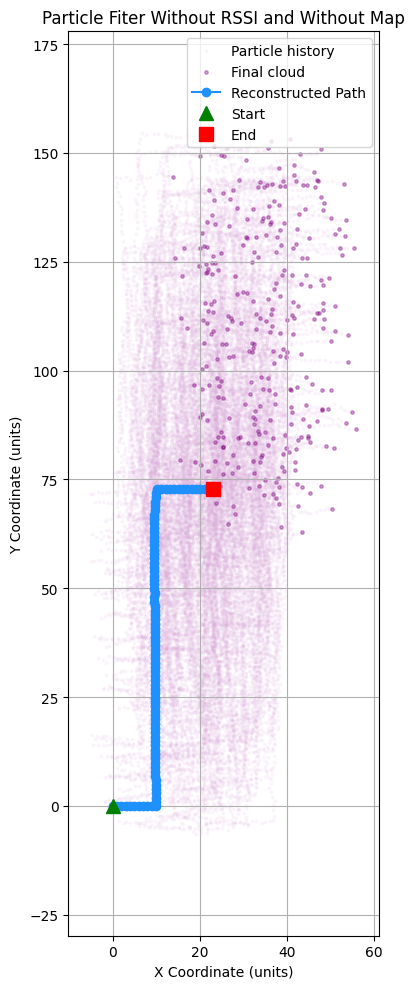

In [10]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import random
import pygame
import cv2

# Configuration
CSV_FILE_PATH = 'test2.csv'
STEP_THRESHOLD = 1.34
MIN_STEP_DISTANCE = 4
STEP_LENGTH = 1.0
NUM_PARTICLES = 300
STEP_NOISE = 0.3
FPS = 10
RECORD_VIDEO = True
VIDEO_FILE = "particle_filter_without_rssi_without_map.mp4"

# 1. Load the dataset
df = pd.read_csv(CSV_FILE_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['acc_magnitude'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)

# 2. Prepare data and detect steps
step_indices, _ = find_peaks(
    df['acc_magnitude'],
    height=STEP_THRESHOLD,
    distance=MIN_STEP_DISTANCE
)
total_steps = len(step_indices)
print(f"Found {total_steps} steps. Reconstructing path...")

# 3. Reconstruct the path using heading (yaw) at each step
path_x = [0]
path_y = [0]
for i in range(total_steps):
    current_yaw_rad = np.deg2rad(df['yaw'].iloc[step_indices[i]])
    delta_x = STEP_LENGTH * np.cos(current_yaw_rad)
    delta_y = STEP_LENGTH * np.sin(current_yaw_rad)
    path_x.append(path_x[-1] + delta_x)
    path_y.append(path_y[-1] + delta_y)
heading_path = list(zip(path_x, path_y))

# Particle Filter Visualization
MIN_X, MAX_X = int(min(path_x)) - 5, int(max(path_x)) + 5
MIN_Y, MAX_Y = int(min(path_y)) - 5, int(max(path_y)) + 5
MAX_SCREEN_W, MAX_SCREEN_H = 1920, 1080
CELL_PX = 18
while True:
    SCREEN_W = int((MAX_X - MIN_X + 1) * CELL_PX)
    SCREEN_H = int((MAX_Y - MIN_Y + 1) * CELL_PX)
    if SCREEN_W <= MAX_SCREEN_W and SCREEN_H <= MAX_SCREEN_H:
        break
    CELL_PX -= 1
    if CELL_PX < 2:
        raise RuntimeError("Unable to fit window in allowed screen size.")

def world_to_screen(x, y):
    return int((x - MIN_X) * CELL_PX), int((MAX_Y - y) * CELL_PX)

def initialize_particles(n):
    xs = np.random.uniform(MIN_X, MAX_X, size=n)
    ys = np.random.uniform(MIN_Y, MAX_Y, size=n)
    return list(zip(xs, ys))

def motion_update(particles, dx, dy):
    return [(x + dx + random.gauss(0, STEP_NOISE), y + dy + random.gauss(0, STEP_NOISE)) for (x, y) in particles]

# Init Pygame
pygame.init()
screen = pygame.display.set_mode((SCREEN_W, SCREEN_H))
pygame.display.set_caption("Particle Filter – Without RSSI and Without Map")
writer = None
if RECORD_VIDEO:
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(VIDEO_FILE, fourcc, FPS, (SCREEN_W, SCREEN_H))

WHITE = (255, 255, 255)
BLUE = (0, 0, 255)
CYAN = (0, 200, 255)
PURPLE = (160, 32, 240)

particles = initialize_particles(NUM_PARTICLES)
particle_history = [particles.copy()]
clock, step_idx, running = pygame.time.Clock(), 1, True

while running:
    if step_idx < len(heading_path):
        prev, curr = heading_path[step_idx - 1], heading_path[step_idx]
        dx, dy = curr[0] - prev[0], curr[1] - prev[1]
        particles = motion_update(particles, dx, dy)
        particle_history.append(particles.copy())
        step_idx += 1

    screen.fill(WHITE)
    for x, y in heading_path[:step_idx]:
        pygame.draw.circle(screen, CYAN, world_to_screen(x, y), 3)
    for x, y in particles:
        pygame.draw.circle(screen, PURPLE, world_to_screen(x, y), 2)
    pygame.draw.circle(screen, BLUE, world_to_screen(*heading_path[0]), 6)
    pygame.draw.circle(screen, BLUE, world_to_screen(*heading_path[-1]), 6)
    pygame.display.flip()

    if RECORD_VIDEO and writer is not None:
        frame = pygame.surfarray.array3d(screen)
        frame = np.transpose(frame, (1, 0, 2))
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        writer.write(frame)

    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
    clock.tick(FPS)

if RECORD_VIDEO and writer is not None:
    writer.release()
pygame.quit()

# Final Matplotlib plot
x_path, y_path = zip(*heading_path)
all_x, all_y = [], []
for frame in particle_history:
    xs, ys = zip(*frame)
    all_x.extend(xs)
    all_y.extend(ys)

plt.figure(figsize=(4, 10))
plt.scatter(all_x, all_y, color='plum', s=3, alpha=0.08, label='Particle history')
final_x, final_y = zip(*particle_history[-1])
plt.scatter(final_x, final_y, color='purple', s=6, alpha=0.35, label='Final cloud')
plt.plot(x_path, y_path, 'o-', color='dodgerblue', label='Reconstructed Path')
plt.plot(x_path[0], y_path[0], 'g^', markersize=10, label='Start')
plt.plot(x_path[-1], y_path[-1], 'rs', markersize=10, label='End')
plt.xlabel("X Coordinate (units)")
plt.ylabel("Y Coordinate (units)")
plt.title("Particle Fiter Without RSSI and Without Map")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()


### 4. Without RSSI and With Map

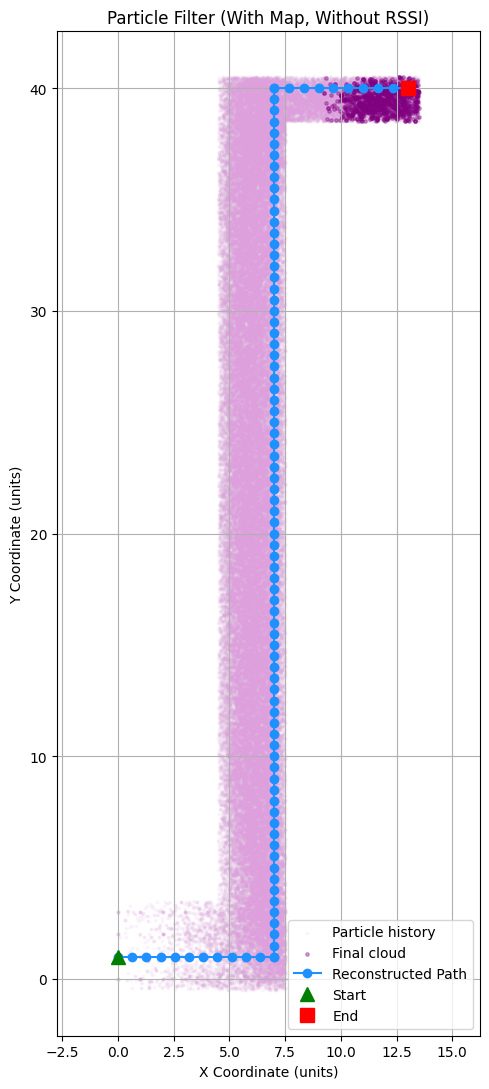

In [ ]:
import pygame
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt

# CONFIGURATION
CELL_PX = 18
WIDTH = 18
HEIGHT = 45
WHITE  = (255, 255, 255)
BLACK  = (0, 0, 0)
BLUE   = (0, 0, 255)
CYAN   = (0, 200, 255)
PURPLE = (160, 32, 240)

NUM_PARTICLES = 1000
STEP_NOISE    = 0.30
RECORD_VIDEO  = True
VIDEO_FILE    = "particle_filter_without_rssi_with_map.mp4"
FPS           = 10

# FLOOR MAP (L-shaped)
def build_floor_map():
    fmap = np.zeros((HEIGHT, WIDTH), dtype=int)
    fmap[0:4,   0:8]  = 1
    fmap[0:4,   0:6]  = 1
    fmap[4:39,  5:8]  = 1
    fmap[39:41, 5:14] = 1
    return fmap

def list_valid_positions(fmap):
    return [(x, y)
            for y in range(HEIGHT)
            for x in range(WIDTH)
            if fmap[y, x] == 1]

def is_valid_particle(x, y, fmap):
    mx = int(round(x))
    my = int(round(y))
    if mx < 0 or mx >= WIDTH or my < 0 or my >= HEIGHT:
        return False
    return fmap[my, mx] == 1

def enforce_valid_particles(particles, fmap):
    valid = [p for p in particles if is_valid_particle(p[0], p[1], fmap)]
    invalid_count = len(particles) - len(valid)
    if invalid_count <= 0:
        return particles
    if not valid:
        return initialize_particles(fmap, len(particles))
    replacements = random.choices(valid, k=invalid_count)
    return valid + replacements

def initialize_particles(fmap, n):
    valid_positions = list_valid_positions(fmap)
    particles = random.choices(valid_positions, k=n)
    return [(float(x), float(y)) for x, y in particles]

def motion_update(particles, dx, dy, fmap):
    updated = []
    for x, y in particles:
        nx = x + dx + random.gauss(0, STEP_NOISE)
        ny = y + dy + random.gauss(0, STEP_NOISE)
        updated.append((nx, ny))
    return enforce_valid_particles(updated, fmap)

# PATH CONSTRUCTION 
def interpolate_path(start, end, step_length):
    dx = end[0] - start[0]
    dy = end[1] - start[1]
    dist = max(abs(dx), abs(dy))
    if dist == 0:
        return [start]
    steps = int(dist / step_length)
    path = []
    for i in range(steps + 1):
        t = i / steps
        x = start[0] + t * dx
        y = start[1] + t * dy
        path.append((x, y))
    return path

def build_heading_path():
    p  = interpolate_path((0, 1),  (7, 1),  0.615)
    p += interpolate_path((7, 1),  (7, 40), 0.50)
    p += interpolate_path((7, 40), (13, 40), 0.615)
    return p

# DRAWING
def draw_map(screen, fmap, heading_path, particles):
    screen.fill(WHITE)
    # Draw walls
    for y in range(HEIGHT):
        for x in range(WIDTH):
            if fmap[y, x] == 1:
                screen_x = x * CELL_PX
                screen_y = (HEIGHT - 1 - y) * CELL_PX
                if y + 1 >= HEIGHT or fmap[y + 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x + CELL_PX, screen_y), 2)
                if y - 1 < 0 or fmap[y - 1, x] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y + CELL_PX), (screen_x + CELL_PX, screen_y + CELL_PX), 2)
                if x + 1 >= WIDTH or fmap[y, x + 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x + CELL_PX, screen_y), (screen_x + CELL_PX, screen_y + CELL_PX), 2)
                if x - 1 < 0 or fmap[y, x - 1] == 0:
                    pygame.draw.line(screen, BLACK, (screen_x, screen_y), (screen_x, screen_y + CELL_PX), 2)
    # Path
    for x, y in heading_path:
        cx = int(x * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - y) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, CYAN, (cx, cy), 3)
    # Particles
    for x, y in particles:
        cx = int(x * CELL_PX + CELL_PX / 2)
        cy = int((HEIGHT - 1 - y) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, PURPLE, (cx, cy), 2)
    # Start & End
    if heading_path:
        cx, cy = int(heading_path[0][0] * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - heading_path[0][1]) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, BLUE, (cx, cy), 6)
        cx, cy = int(heading_path[-1][0] * CELL_PX + CELL_PX / 2), int((HEIGHT - 1 - heading_path[-1][1]) * CELL_PX + CELL_PX / 2)
        pygame.draw.circle(screen, BLUE, (cx, cy), 6)
    pygame.display.flip()

# MAIN
def main():
    fmap = build_floor_map()
    heading_path = build_heading_path() 
    particles = initialize_particles(fmap, NUM_PARTICLES)
    particle_history = [particles.copy()]

    pygame.init()
    screen = pygame.display.set_mode((WIDTH * CELL_PX, HEIGHT * CELL_PX))
    pygame.display.set_caption("Particle Filter – With Map, Without RSSI")

    writer = None
    if RECORD_VIDEO:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        frame_size = (WIDTH * CELL_PX, HEIGHT * CELL_PX)
        writer = cv2.VideoWriter(VIDEO_FILE, fourcc, FPS, frame_size)

    clock = pygame.time.Clock()
    step_idx = 1
    running = True

    while running:
        if step_idx < len(heading_path):
            prev = heading_path[step_idx - 1]
            curr = heading_path[step_idx]
            dx, dy = curr[0] - prev[0], curr[1] - prev[1]
            particles = motion_update(particles, dx, dy, fmap)
            particle_history.append(particles.copy())
            step_idx += 1

        draw_map(screen, fmap, heading_path[:step_idx], particles)

        if RECORD_VIDEO and writer is not None:
            frame = pygame.surfarray.array3d(screen)
            frame = np.transpose(frame, (1, 0, 2))
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            writer.write(frame)

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
        clock.tick(FPS)

    if RECORD_VIDEO and writer is not None:
        writer.release()
    pygame.quit()

    # Matplotlib static plot
    all_x, all_y = [], []
    for frame in particle_history:
        xs, ys = zip(*frame)
        all_x.extend(xs)
        all_y.extend(ys)
    x_path, y_path = zip(*heading_path)
    plt.figure(figsize=(5, 11))
    plt.scatter(all_x, all_y, color='plum', s=3, alpha=0.08, label='Particle history')
    fx, fy = zip(*particle_history[-1])
    plt.scatter(fx, fy, color='purple', s=6, alpha=0.35, label='Final cloud')
    plt.plot(x_path, y_path, 'o-', color='dodgerblue', label='Reconstructed Path')
    plt.plot(x_path[0],  y_path[0],  'g^', markersize=10, label='Start')
    plt.plot(x_path[-1], y_path[-1], 'rs', markersize=10, label='End')
    plt.xlabel("X Coordinate (units)")
    plt.ylabel("Y Coordinate (units)")
    plt.title("Particle Filter (With Map, Without RSSI)")
    plt.grid(True)
    plt.legend()
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


# Comparison and discussion of the results

## Comparison and Discussion of Results: Particle Filter Accuracy Across Configurations

To better understand the role of map constraints and RSSI in indoor localization, we evaluated the particle filter across four key configurations. Each setup demonstrates how different sensor combinations impact localization performance in terms of accuracy, path adherence, and particle behavior.

---

### 1. Particle Filter with Map and RSSI (Ideal Case)

This is the most complete and ideal scenario. The map ensures particles remain in walkable areas, while the RSSI provides absolute distance cues from known beacon positions. Together, they complement the IMU’s step-based movement.

- **Observation**: The estimated path is highly accurate, smoothly following the true trajectory and capturing turns correctly.
- **Particle Behavior**: The particles stay constrained within the defined corridors and adjust naturally near beacons.
- **Conclusion**: Combining map constraints, RSSI-based distance estimates, and IMU dead reckoning yields the most robust and precise localization. It corrects drift and avoids impossible movements (like walking through walls).

---

### 2. Particle Filter with Map but Without RSSI

In this setup, particles are constrained by the map but do not receive any beacon signals (RSSI). As a result, particles rely entirely on step detection and heading from the IMU.

- **Observation**: The path generally follows the correct corridor, but we start seeing some drift along the walking direction, especially toward the end.
- **Particle Behavior**: Particles are confined within valid areas due to the map, but there's no correction from external references like beacons.
- **Conclusion**: Without RSSI, the system depends solely on the IMU. While the map keeps particles in legal areas, there's no way to correct accumulated distance errors (e.g., under- or over-estimated step length). The trajectory is plausible but not as accurate as the ideal case.

---

### 3. Particle Filter with RSSI but Without Map

This case uses RSSI for distance estimation and IMU for movement, but no map is applied to eliminate implausible particles.

- **Observation**: The path somewhat follows the intended direction, and beacons can still be detected using RSSI. However, without map constraints, particles are free to drift into non-walkable areas.
- **Particle Behavior**: The particles follow the IMU direction and get pulled toward beacon signals, but because there’s no wall-checking, some particles float into impossible positions (like through walls).
- **Conclusion**: We can partially detect beacons and roughly localize, but the absence of a map leads to instability. There's no particle "killing" or boundary enforcement, so the final result is noisy and less reliable. It highlights the importance of maps in filtering out implausible estimates.

---

### 4. Particle Filter Without Map and Without RSSI (Only IMU)

This is the most limited configuration. The particle filter relies solely on IMU data, with no map or beacon input.

- **Observation**: The trajectory quickly deviates from the real path, especially after turns or long straight segments.
- **Particle Behavior**: Without external corrections, particles simply follow the IMU’s perceived movement. Over time, heading and step-length errors accumulate, causing large drift.
- **Conclusion**: With no map and no RSSI, the system cannot self-correct. The particles are unbounded and can move unrealistically, resulting in significant error. This configuration is unsuitable for reliable indoor localization.

---

### Summary

This comparison clearly demonstrates how each component contributes:
- **Map**: Enforces environmental constraints and prevents implausible paths.
- **RSSI**: Provides absolute positioning cues and helps correct drift.
- **IMU**: Provides continuous step-based updates but needs support from map and RSSI to stay accurate.

The **fusion of all three (IMU + Map + RSSI)** is necessary for high-accuracy, drift-resistant indoor localization.
